In [2]:
 import numpy as np
 import pandas as pd
 import matplotlib.pyplot as plt
 import seaborn as sns
 from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

 # setting style for grids and supressing warnings to keep notebook clean
 sns.set_theme(style="whitegrid")
 plt.rcParams['figure.figsize']=(16,6)
 import warnings
 warnings.filterwarnings('ignore')


# TASK 1- Data Loading, Merging and Deep Exploration

In [3]:
# Loading train.csv using Pandas
df=pd.read_csv("train.csv")
print(df.head(5))

# Parsing Order Date and Ship Date and converting them into datetime objects
df['Order Date']=pd.to_datetime(df['Order Date'],format='%d/%m/%Y')
df['Ship Date']=pd.to_datetime(df['Ship Date'],format='%d/%m/%Y')
print(df.info())

#Extracting time features Year, Month, Week Number, Day of Week, Quarter, Season
df['Year']=df['Order Date'].dt.year
df['Month']=df["Order Date"].dt.month
df['Week Number']=df['Order Date'].dt.isocalendar().week
df['Day of Week']=df['Order Date'].dt.day_name()
df['Quarter']=df['Order Date'].dt.quarter
def get_season(month):
  if month in (12,1,2):
    return 'Winter'
  elif month in (3,4,5):
    return 'Spring'
  elif month in (6,7,8):
    return 'Summer'
  else:
    return 'Autumn'

df['Season']=df['Month'].apply(get_season)

df[['Order Date','Year','Month','Week Number','Day of Week','Quarter','Season']].head(3)

# Checking for missing values, duplicates and data type issues
print(df.isnull().sum())
print(df.duplicated())
df.drop_duplicates
print(df.dtypes)
print(df.describe())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

CATEGORY WITH HIGHEST REVENUE
Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64
 
MOST CONSISTENT SALES GROWTH
Year            2015         2016         2017         2018
Region                                                     
Central  102920.5206  102425.1724  145673.8800  141627.3402
East     127652.8190  153225.1830  178511.5380  210129.1860
South    103374.9055   70076.0825   93535.9035  122164.5675
West     145907.9630  133709.5675  182471.2285  248130.9255
Overall delay time:  3.96 days 

 Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Delay, dtype: float64




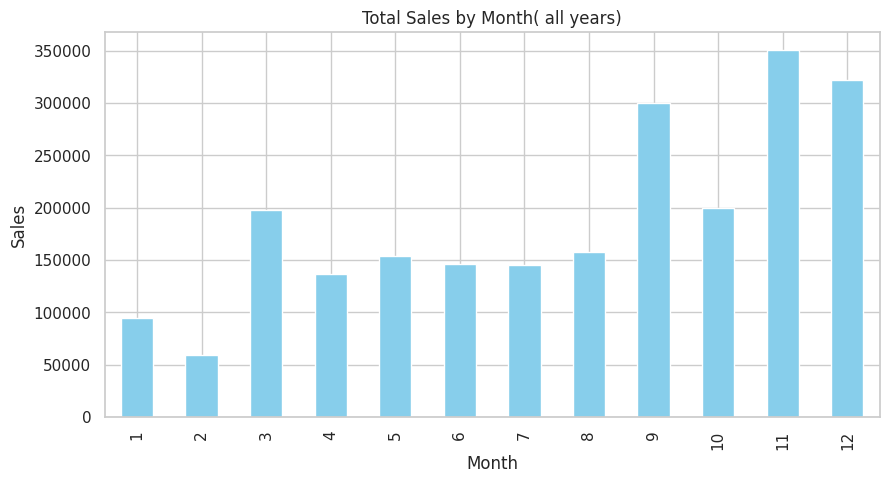

In [4]:
# Product Category that has highest total revenue
print("CATEGORY WITH HIGHEST REVENUE")
category_revenue= df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_revenue)
# We found out that the highest revenue is earned by Technology Category with a total revenue of $827455

# Region that has the most consistent sales growth over 4 years
print(" \nMOST CONSISTENT SALES GROWTH")
consistent_sales=df.groupby(['Region','Year'])['Sales'].sum().unstack()
print(consistent_sales)
# From all the growth statistics, we observe that the East region has the most consistent and upward growth, hence ans is -EAST

# What is the average time between Ship Date and Order Date and does it vary by region
df['Shipping Delay']= (df['Ship Date']- df['Order Date']).dt.days
print(f"Overall delay time: {df['Shipping Delay'].mean(): .2f} days ")
avg_delay_region= df.groupby('Region')['Shipping Delay'].mean().sort_values()
print(f"\n {avg_delay_region}")
# Central Region shows most delay, however not much difference is there as all hover around the 4 day mark

# Are there months that consistenly spike across all years(seasonality)?
print("\n")
monthly_seasonality=df.groupby('Month')['Sales'].sum()
monthly_seasonality.plot(kind='bar', figsize=(10,5),color='skyblue')
plt.title('Total Sales by Month( all years)')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()
plt.close()
# November(11th Month) shows the maximum number of sales- we can infer this from the bar plot

# TASK 2- Time Series Analysis and Decomposition


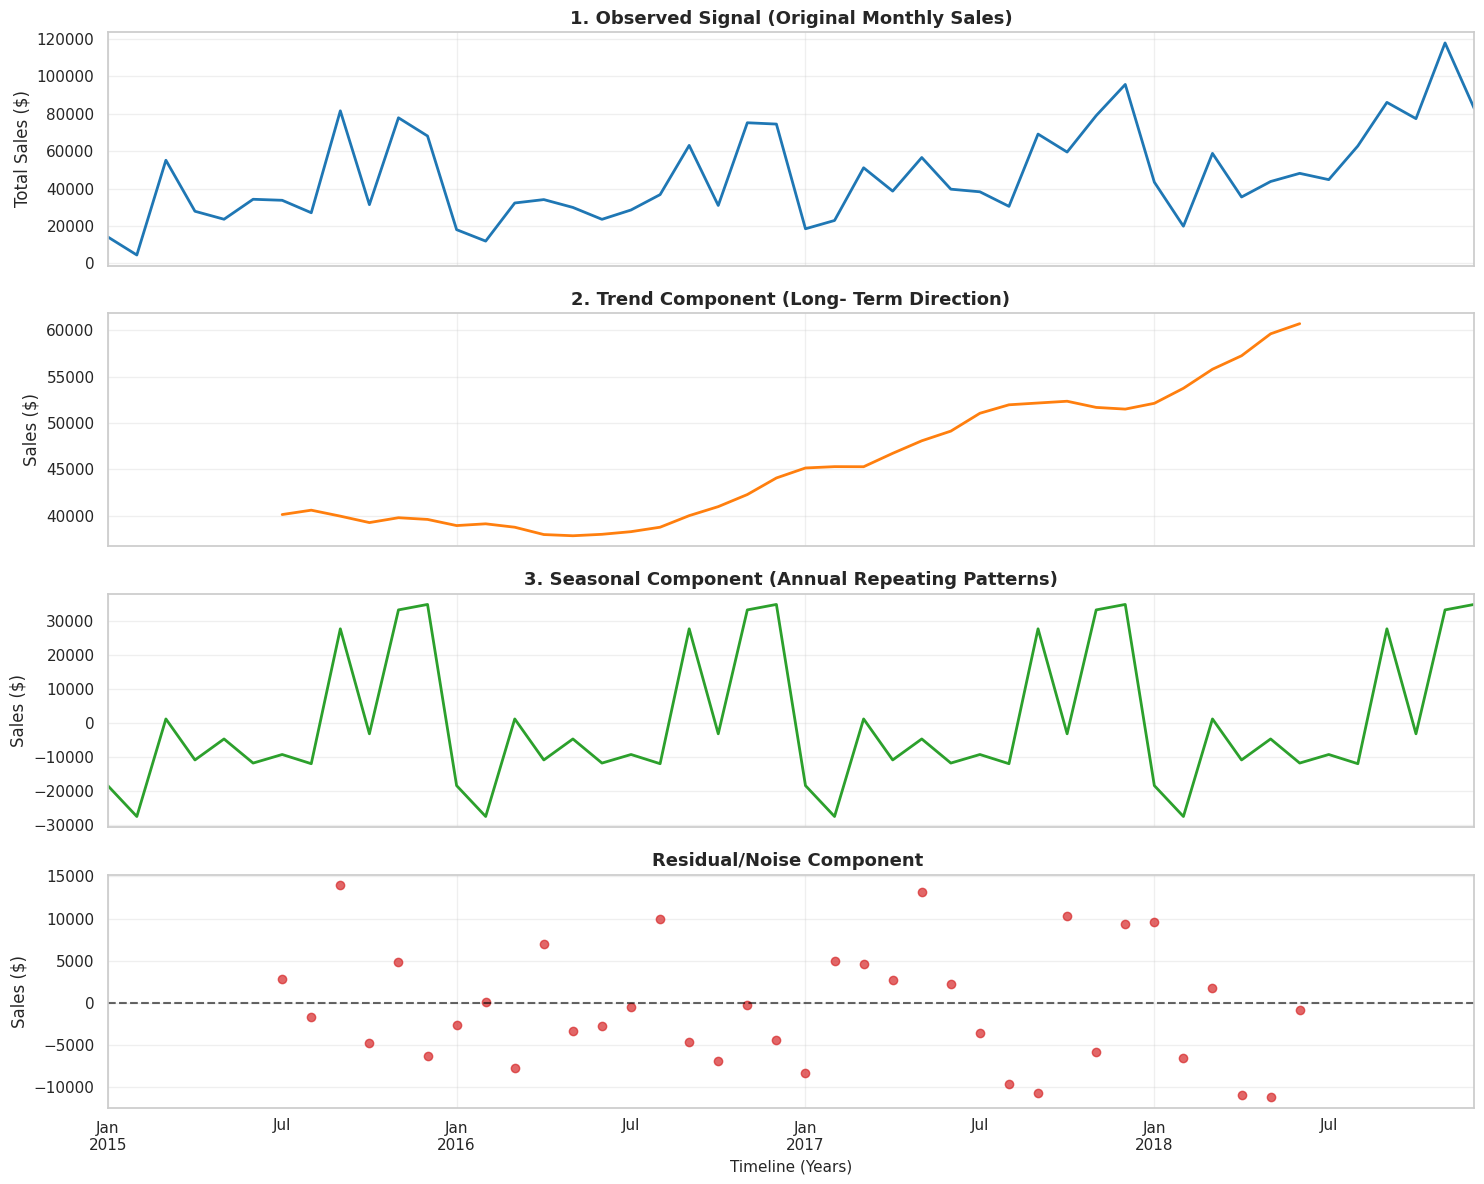

In [5]:
# Plot the overall monthly sales trend across all four years
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

if 'Order Date' in df.columns:
    monthly_sales = df.set_index('Order Date').resample('MS')['Sales'].sum()
else:
    monthly_sales = df['Sales'].resample('MS').sum()

decomposition= seasonal_decompose(monthly_sales, model='additive') #applying time series decomposition using additive model that handles fixed seasonality

fig,axes=plt.subplots(4,1,figsize=(15,12),sharex=True) #Plotting all 4 components in one figure only

# Component 1 : Observed (Original Data)
decomposition.observed.plot(ax=axes[0],color='#1f77b4',lw=2)
axes[0].set_title('1. Observed Signal (Original Monthly Sales)',fontsize=13,fontweight='bold')
axes[0].set_ylabel('Total Sales ($)')
axes[0].grid(True,alpha=0.3)

# Component 2 : Trend
decomposition.trend.plot(ax=axes[1],color='#ff7f0e',lw=2)
axes[1].set_title('2. Trend Component (Long- Term Direction)',fontsize=13, fontweight='bold')
axes[1].set_ylabel('Sales ($)')
axes[1].grid(True, alpha=0.3)

# Component 3: Seasonal
decomposition.seasonal.plot(ax=axes[2],color='#2ca02c',lw=2)
axes[2].set_title('3. Seasonal Component (Annual Repeating Patterns)',fontsize=13,fontweight='bold')
axes[2].set_ylabel('Sales ($)')
axes[2].grid(True,alpha=0.3)

# Component 4: Residuals (Noise)
decomposition.resid.plot(ax=axes[3],color='#d62728',marker='o',linestyle='none',alpha=0.7)
axes[3].axhline(0,color='black',linestyle='--',alpha=0.6)
axes[3].set_title('Residual/Noise Component ',fontsize=13,fontweight='bold')
axes[3].set_ylabel('Sales ($)')
axes[3].grid(True,alpha=0.3)

plt.xlabel('Timeline (Years)',fontsize=11)
plt.tight_layout()
plt.show()
plt.close()


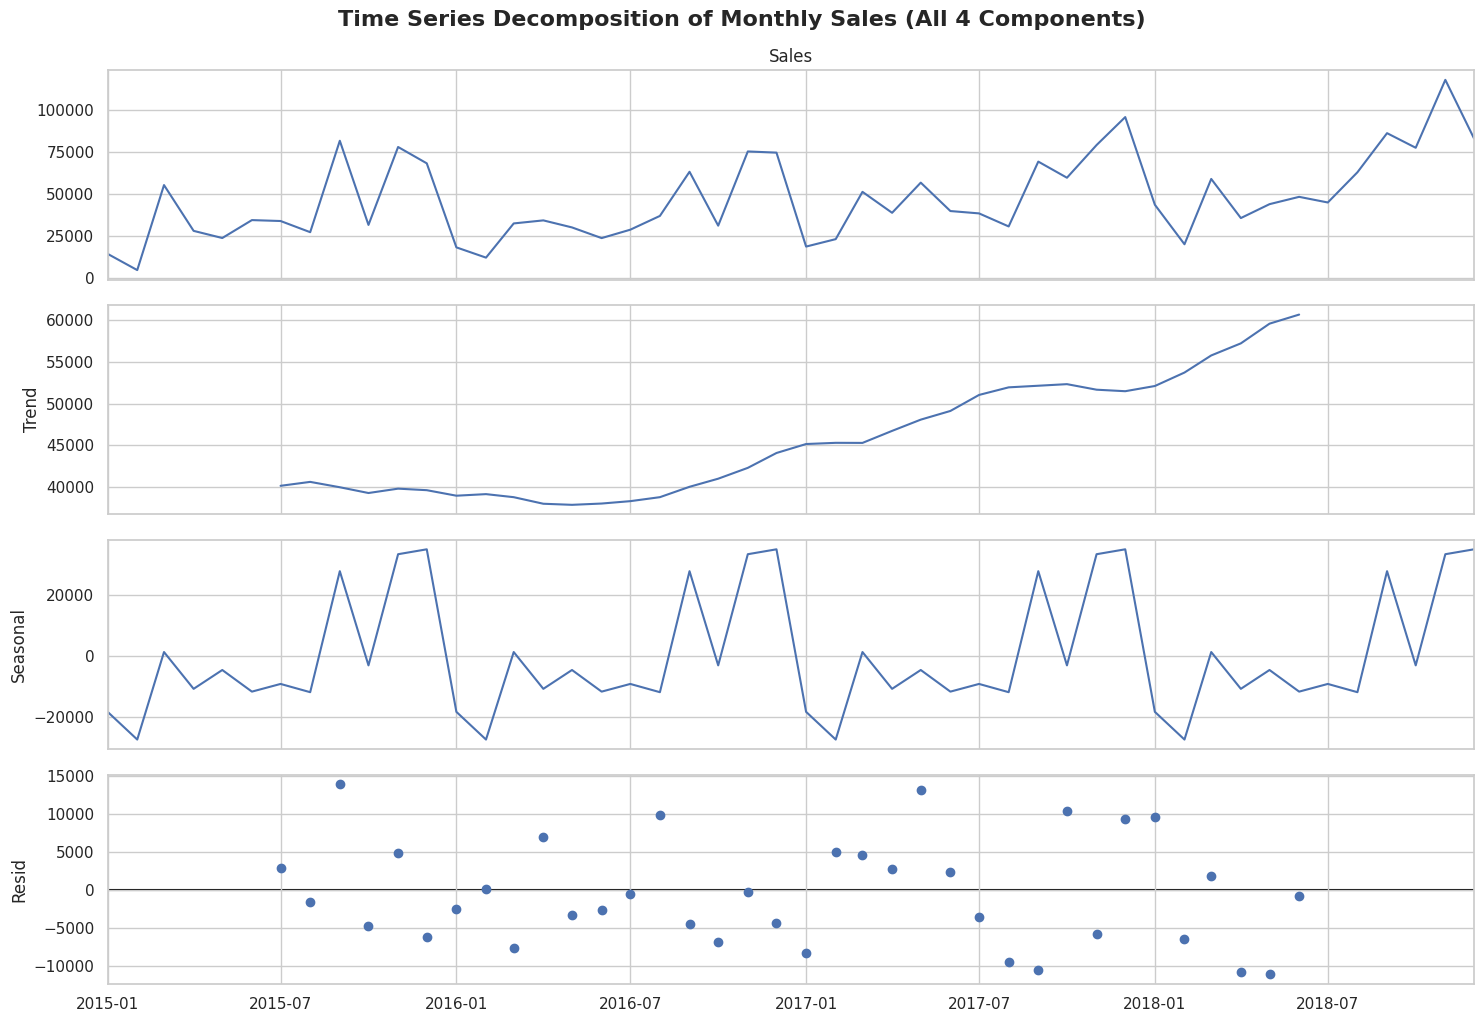

In [6]:
plt.rc('figure',figsize=(15,10))
fig=decomposition.plot()
fig.suptitle('Time Series Decomposition of Monthly Sales (All 4 Components)', fontsize=16, fontweight='bold', y=1.02)
plt.show()
plt.close()

Step 1: Performing the Augmented Dickey-Fuller Test
ADF Statistic: -4.4161
p-value: 0.0003

 Series is already Stationary so no differencing required


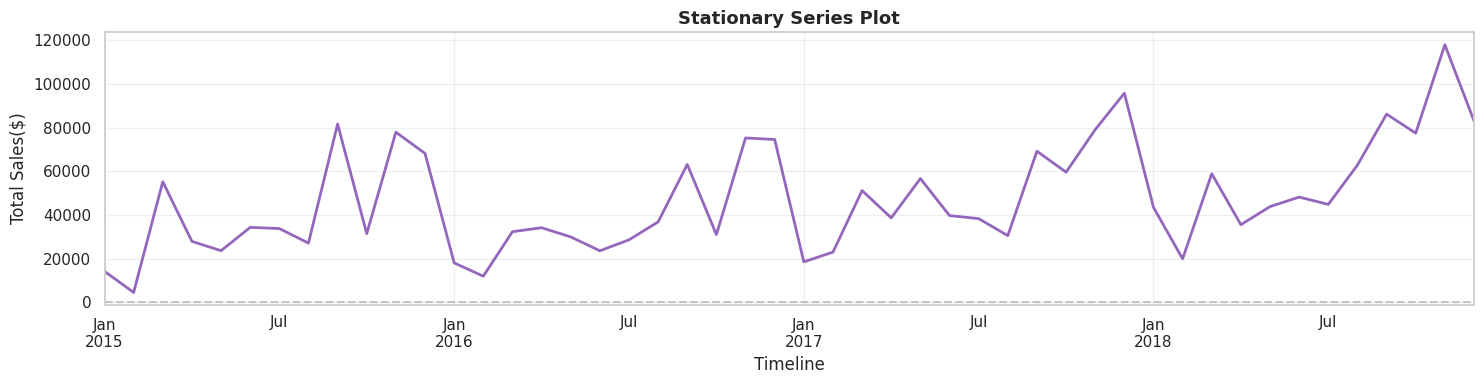

In [7]:
# Check for stationarity using the Augmented Dickey-Fuller (ADF) Test
# explain in plain English what stationarity means and what your test result tells you
print("="*50)
print('Step 1: Performing the Augmented Dickey-Fuller Test')
print("="*50)
result_orig=adfuller(monthly_sales)
print(f"ADF Statistic: {result_orig[0]:.4f}")
print(f"p-value: {result_orig[1]:.4f}")
if result_orig[1]<=0.05:
  print("\n Series is already Stationary so no differencing required")
else:
  print("\n Series is not Stationary hence differencing is required")
# We find out that the series was stationary and differencing is not required

# Plotting the stationary Series
plt.figure(figsize=(15,4))
monthly_sales.plot(color='#9467bd',lw=2)
plt.axhline(0,color='black',linestyle='--',alpha=0.2)
plt.title('Stationary Series Plot',fontsize=13,fontweight='bold')
plt.ylabel('Total Sales($)')
plt.xlabel('Timeline')
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

# TASK 3 - SALES FORECASTING USING 3 DIFFERENT MODELS

#### 1. SARIMA (Statistical Model)


 SARIMA EVALUATION METRICS


 MEAN ABSOLUTE ERROR: 20581.00

 MEAN SQUARED ERROR : 22191.27

 MEAN ABSOLUTE PERCENTAGE ERROR : 21.94



 SARIMA 3 MONTHS FORECAST
Month 1 Forecast: $54,758.51
Month 2 Forecast: $88,412.60
Month 3 Forecast: $92,558.21


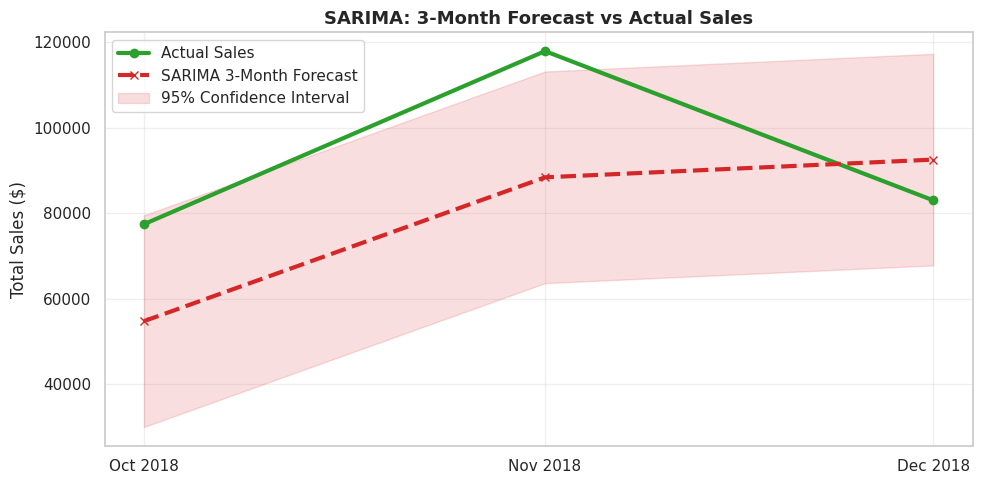

In [8]:
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error

train=monthly_sales.iloc[:-3]
test=monthly_sales.iloc[-3:]

model=sm.tsa.statespace.SARIMAX(
    train,
    order=(1,0,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False

)

sarima_res=model.fit(disp=False)
sarima_pred=sarima_res.get_forecast(steps=3).summary_frame()['mean']
sarima_pred.index=test.index

# Getting the confidence intervals
forecast_frame=sarima_res.get_forecast(steps=3).summary_frame()
lower_ci=forecast_frame['mean_ci_lower'].values
upper_ci=forecast_frame['mean_ci_upper'].values
sarima_pred_series=pd.Series(sarima_pred,test.index)
mae_s=mean_absolute_error(test,sarima_pred)
rmse_s=np.sqrt(mean_squared_error(test,sarima_pred))
mape_s=np.mean(np.abs((test - sarima_pred) / test)) * 100

print("\n SARIMA EVALUATION METRICS")
print(f"\n\n MEAN ABSOLUTE ERROR: {mae_s:.2f}")
print(f"\n MEAN SQUARED ERROR : {rmse_s:.2f}")
print(f"\n MEAN ABSOLUTE PERCENTAGE ERROR : {mape_s:.2f}")


print("\n\n\n SARIMA 3 MONTHS FORECAST")
for i, val in enumerate(sarima_pred, 1):
    print(f"Month {i} Forecast: ${val:,.2f}")

# Plotting the Results with Actual Values
plt.figure(figsize=(10, 5))

plt.plot(test.index, test, label='Actual Sales', color='#2ca02c', marker='o', lw=3)
plt.plot(sarima_pred.index, sarima_pred_series, label='SARIMA 3-Month Forecast', color='#d62728', marker='x', lw=3, linestyle='--')
plt.fill_between(test.index, lower_ci, upper_ci, color='#d62728', alpha=0.15, label='95% Confidence Interval')

# Format the X-axis to show the specific months clearly
plt.gca().set_xticks(test.index)
plt.gca().set_xticklabels([d.strftime('%b %Y') for d in test.index])

plt.title('SARIMA: 3-Month Forecast vs Actual Sales', fontsize=13, fontweight='bold')
plt.ylabel('Total Sales ($)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


2. FACEBOOK PROPHET

           ds           y
40 2018-05-01  43825.9822
41 2018-06-01  48190.7277
42 2018-07-01  44825.1040
43 2018-08-01  62837.8480
44 2018-09-01  86152.8880
Figure(1000x800)


     REGULARIZED WEEKLY COMPONENTS
Monday          : $7,703.41
Tuesday         : $-3,689.00
Wednesday       : $2,352.06
Thursday        : $-3,428.82
Friday          : $-1,148.23
Saturday        : $-2,947.06
Sunday          : $1,157.64


     REGULARIZED YEARLY COMPONENTS
January         : $-20,937.14
February        : $-30,879.61
March           : $7,157.61
April           : $-10,890.27
May             : $-8,298.05
June            : $-11,028.88
July            : $-10,349.70
August          : $-8,446.40
September       : $30,410.45
October         : $-2,840.28
November        : $31,619.77
December        : $34,889.13
     


FACEBOOK PROPHET EVALUATION METRICS      

MEAN ABSOLUTE ERROR: 18207.58
MEAN SQUARED ERROR: 20752.86
MEAN ABSOLUTE PERCENTAGE ERROR: 18.59



Month 1 Forecast (Oct): $62,582.85
Month 2 Forecas

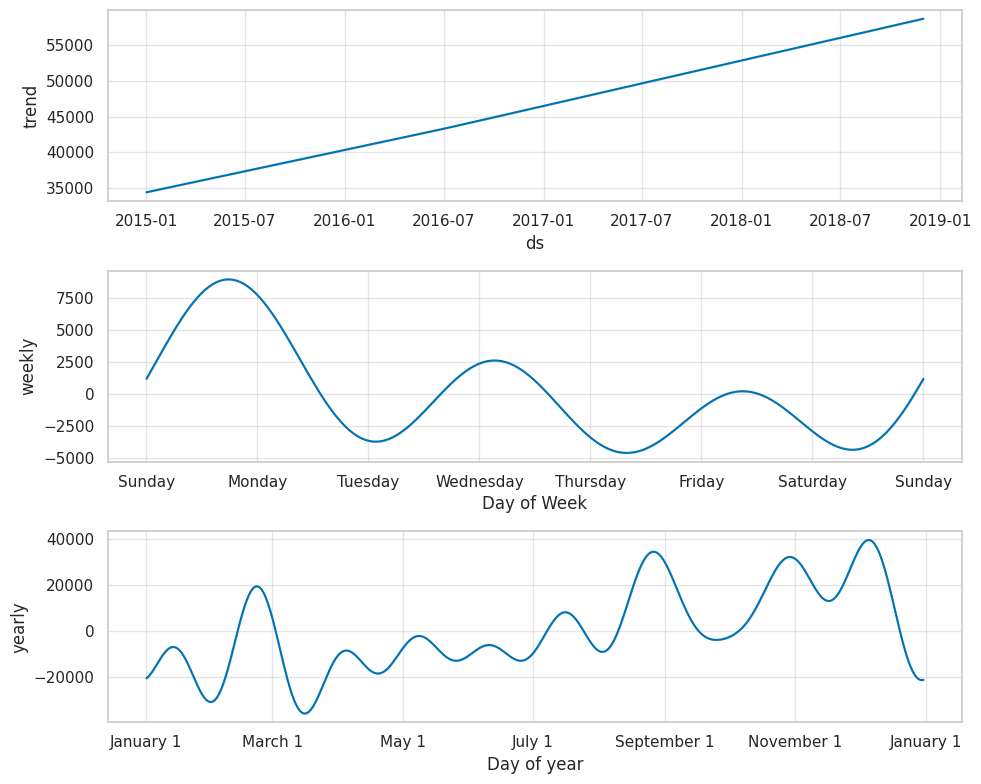

In [9]:
# 1. Installing Prophet
#colab already has prophet preinstalled so we do not require installation

# 2. Preparing data in prophet's required format (ds,y)
prophet_df=monthly_sales.reset_index()
prophet_df.columns=['ds','y']

# stripping out timezone information to prevent format errors
prophet_df['ds']=prophet_df['ds'].dt.tz_localize(None)

# Splitting data into training and testing sets
train_p = prophet_df.iloc[:-3]
test_p = prophet_df.iloc[-3:]

print(train_p.tail())

# Fitting the model and generate a 3-month forecast
from prophet import Prophet
model_p=Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False,seasonality_prior_scale=0.1)
model_p.fit(train_p)
future = model_p.make_future_dataframe(periods=3, freq='MS')
forecast=model_p.predict(future)
forecast_future = forecast[['ds', 'yhat']].tail(3)
forecast_future.columns = ['Date', 'Sales']
forecast_future.to_csv("forecast.csv", index=False)
forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(3)

# Plotting the forecast with Prophet's built-in trend and seasonality breakdown

fig2=model_p.plot_components(forecast,figsize=(10,8))
print(fig2)

# Extracting and interpret the weekly and yearly seasonality components
weekly_df=forecast[['ds','weekly']].copy()
weekly_df['Day_of_week']= weekly_df['ds'].dt.day_name()
weekly_effects=weekly_df.groupby('Day_of_week')['weekly'].first()
days_order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekly_effects=weekly_effects.reindex(days_order)

yearly_df=forecast[['ds','yearly']].copy()
yearly_df['Month'] = yearly_df['ds'].dt.strftime('%B')


monthly_effects = yearly_df.groupby('Month')['yearly'].first()
months_order = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']
monthly_effects = monthly_effects.reindex(months_order)
print("\n\n     REGULARIZED WEEKLY COMPONENTS")
for day, val in weekly_effects.items():
    print(f"{day:<15} : ${val:,.2f}")

print("\n\n     REGULARIZED YEARLY COMPONENTS")
for month, val in monthly_effects.items():
    print(f"{month:<15} : ${val:,.2f}")


# calculating mse, mae and mape for prophet
y_test_p=test_p['y'].values
prophet_preds = forecast['yhat'].iloc[-3:].values

mae_prp = mean_absolute_error(y_test_p, prophet_preds)
rmse_prp = np.sqrt(mean_squared_error(y_test_p, prophet_preds))
mape_prp = mean_absolute_percentage_error(y_test_p, prophet_preds) * 100

print("     \n\n\nFACEBOOK PROPHET EVALUATION METRICS      \n")
print(f"MEAN ABSOLUTE ERROR: {mae_prp:.2f}")
print(f"MEAN SQUARED ERROR: {rmse_prp:.2f}")
print(f"MEAN ABSOLUTE PERCENTAGE ERROR: {mape_prp:.2f}")

# printing forecast for the next 3 months
print(f"\n\n\nMonth 1 Forecast (Oct): ${prophet_preds[0]:,.2f}")
print(f"Month 2 Forecast (Nov): ${prophet_preds[1]:,.2f}")
print(f"Month 3 Forecast (Dec): ${prophet_preds[2]:,.2f}")


 INTEPRETATION OF THE WEEKLY AND YEARLY SEASONALITY COMPONENTS
 1. YEARLY COMPONENTS:

 From what we have observed, September, November and December see the highest number of sales every year and immediately we see that January and February have very negative components meaning that sales are relatively low in these months. This could be because higher number of sales occur in the festive seasons and lower number of sales occur after festive season is over as people try to cut back on expenses.


2. WEEKLY COMPONENTS:

Since the model is trained on monthly data, it is blind to weeks and does not show actual consumer behaviour. Because the  data is monthly, it lacks granularity. The model is simply misinterpreting pure calender coincidence - specifically, instances where exceptionally high sales months randomly opened on a monday.



### 3. XGBOOST FOR TIME SERIES

In [10]:
df_xgb= monthly_sales.to_frame(name='y')
df_xgb['Month']=df_xgb.index.month
df_xgb['Quarter']=df_xgb.index.quarter
df_xgb['Season']=df_xgb['Month'].map({12:1, 1:1, 2:1, 3:2, 4:2, 5:2, 6:3, 7:3, 8:3, 9:4, 10:4, 11:4})

# Converting time series into data suitable for supervised ml model using lag features
df_xgb['Lag_1']=df_xgb['y'].shift(1)
df_xgb['Lag_2']=df_xgb['y'].shift(2)
df_xgb['Lag_3']=df_xgb['y'].shift(3)

# creating rolling mean feature
df_xgb['Rolling_Mean_3']=df_xgb['y'].shift(1).rolling(window=3).mean()
# dropping first 3 rows because they donot have enough history to compute Lag 3
df_xgb=df_xgb.dropna()


print(df_xgb.head())

                     y  Month  Quarter  Season       Lag_1       Lag_2  \
Order Date                                                               
2015-04-01  27906.8550      4        2       2  55205.7970   4519.8920   
2015-05-01  23644.3030      5        2       2  27906.8550  55205.7970   
2015-06-01  34322.9356      6        2       3  23644.3030  27906.8550   
2015-07-01  33781.5430      7        3       3  34322.9356  23644.3030   
2015-08-01  27117.5365      8        3       3  33781.5430  34322.9356   

                Lag_3  Rolling_Mean_3  
Order Date                             
2015-04-01  14205.707    24643.798667  
2015-05-01   4519.892    29210.848000  
2015-06-01  55205.797    35585.651667  
2015-07-01  27906.855    28624.697867  
2015-08-01  23644.303    30582.927200  


     XGB REGRESSOR EVALUATION METRICS      

    MEAN ABSOLUTE ERROR: 27122.89
    MEAN SQUARED ERROR: 27166.84
    MEAN ABSOLUTE PERCENTAGE ERROR: 30.20



 FORECAST FOR THE NEXT THREE MONTHS
  Month 1 Forecast: $48,793.53
  Month 2 Forecast: $90,232.18
  Month 3 Forecast: $58,022.29


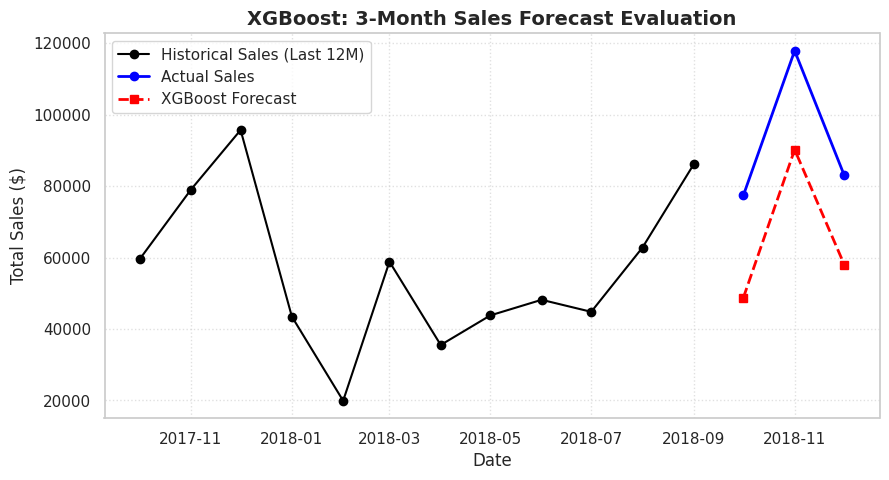

In [11]:
from xgboost import XGBRegressor
feature_cols=['Month','Quarter','Season','Lag_1','Lag_2','Lag_3','Rolling_Mean_3']
X=df_xgb[feature_cols]
y=df_xgb['y']
X_train,X_test=X.iloc[:-3],X.iloc[-3:]
y_train,y_test=y.iloc[:-3],y.iloc[-3:]
xgb_model=XGBRegressor(n_estimators=100, learning_rate=0.1,random_state=42)
xgb_model.fit(X_train,y_train)
xgb_preds=xgb_model.predict(X_test)

# computing mse,mae and mape
xgb_rmse=np.sqrt(mean_squared_error(y_test,xgb_preds))
xgb_mae=mean_absolute_error(y_test,xgb_preds)
xgb_mape=mean_absolute_percentage_error(y_test,xgb_preds)*100

print("     XGB REGRESSOR EVALUATION METRICS      \n")
print(f"    MEAN ABSOLUTE ERROR: {xgb_mae:.2f}")
print(f"    MEAN SQUARED ERROR: {xgb_rmse:.2f}")
print(f"    MEAN ABSOLUTE PERCENTAGE ERROR: {xgb_mape:.2f}")


print("\n\n\n FORECAST FOR THE NEXT THREE MONTHS")
for i, pred in enumerate(xgb_preds, 1):
    print(f"  Month {i} Forecast: ${pred:,.2f}")


# plotting actual vs predicted graph
plt.figure(figsize=(10, 5))
plt.plot(y_train.index[-12:], y_train.iloc[-12:], label='Historical Sales (Last 12M)', color='black', marker='o')
plt.plot(y_test.index, y_test, label='Actual Sales', color='blue', marker='o', linewidth=2)
plt.plot(y_test.index, xgb_preds, label='XGBoost Forecast', color='red', linestyle='--', marker='s', linewidth=2)
plt.title('XGBoost: 3-Month Sales Forecast Evaluation', fontsize=14, fontweight='bold')
plt.ylabel('Total Sales ($)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


In [12]:
comparison_data={
    'Model':['SARIMA','Prophet','XGBoost'],
    'MAE':[20581.00,18207.58,27122.89],
    'RMSE':[22191.27,20752.86,27166.84],
    'MAPE(%)':[21.94,18.59,30.20],
    'Oct Forecast':[54758.51,62582.85,48793.53],
    'Nov Forecast':[88412.60,86211.65,90232.18],
    'Dec Forecast':[92558.21,91061.34,58022.29]
}
df_comparison=pd.DataFrame(comparison_data)
styled_table=df_comparison.style.format({
    'MAE':'${:,.2f}',
    'RMSE':'${:,.2f}',
    'MAPE(%)':'{:.2f}',
    'Oct Forecast':'${:,.2f}',
    'Nov Forecast':'${:,.2f}',
    'Dec Forecast':'${:,.2f}'
}).hide(axis='index')
styled_table

Model,MAE,RMSE,MAPE(%),Oct Forecast,Nov Forecast,Dec Forecast
SARIMA,"$20,581.00","$22,191.27",21.94,"$54,758.51","$88,412.60","$92,558.21"
Prophet,"$18,207.58","$20,752.86",18.59,"$62,582.85","$86,211.65","$91,061.34"
XGBoost,"$27,122.89","$27,166.84",30.20,"$48,793.53","$90,232.18","$58,022.29"


State clearly which model you would recommend for production use and why — based on numbers, not preference.

Ans. I would prefer using Prophet because it has better metrics as compared to the rest of the models. Its MAE is relatively (2000 from SARIMA & $9000 from XGBOOST) shows that it makes lesser error. Similar performance is shown by Prophet in RMSE and MAPE where both its metrics are lesser than SARIMA & XGBoost. Hence we go ahead with Facebook Prophet as our best model.


# TASK 4- Product Category & Region Level Forecasting


Processing segment: Furniture
  -> Oct: $12,146.90 | Nov: $8,295.40 | Dec: $16,046.97
Processing segment: Technology
  -> Oct: $14,854.86 | Nov: $13,319.80 | Dec: $32,004.69
Processing segment: Office Supplies
  -> Oct: $15,120.41 | Nov: $12,291.44 | Dec: $20,496.59
Processing segment: West Region
  -> Oct: $13,771.20 | Nov: $11,636.79 | Dec: $25,071.32
Processing segment: East Region
  -> Oct: $9,720.64 | Nov: $9,838.32 | Dec: $14,533.28


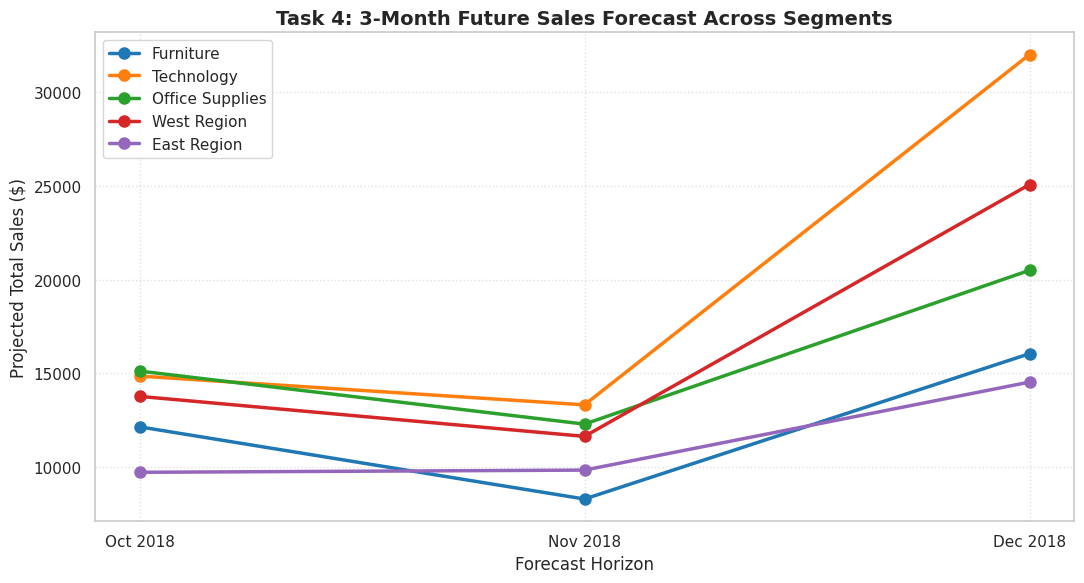

In [13]:
#Repeating the best performing model (Prophet) for segments:Furniture,Technology, Office Supplies, West region and East region sales

#dividing into segments
segments = {
    'Furniture': ('Category', 'Furniture'),
    'Technology': ('Category', 'Technology'),
    'Office Supplies': ('Category', 'Office Supplies'),
    'West Region': ('Region', 'West'),
    'East Region': ('Region', 'East')
}

# dictionary to hold all forecasts together
combined_forecasts={}
for name,(column,value) in segments.items():
  print(f"Processing segment: {name}")
  segment_df = df[df[column] == value].copy()

  monthly_seg = segment_df.resample('MS', on='Order Date')['Sales'].sum().reset_index()
  monthly_seg.columns = ['ds','y']
  monthly_seg['ds'] = monthly_seg['ds'].dt.tz_localize(None)

  model_seg = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False, seasonality_prior_scale=0.1)
  model_seg.fit(monthly_seg)

  future_seg = model_seg.make_future_dataframe(periods=3, freq='MS')
  forecast_seg = model_seg.predict(future_seg)

  future_preds = forecast_seg['yhat'].iloc[-3:].values
  combined_forecasts[name] = future_preds

  print(f"  -> Oct: ${future_preds[0]:,.2f} | Nov: ${future_preds[1]:,.2f} | Dec: ${future_preds[2]:,.2f}")

future_months = ['Oct 2018', 'Nov 2018', 'Dec 2018']

plt.figure(figsize=(11, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, (name, preds) in enumerate(combined_forecasts.items()):
    plt.plot(future_months, preds, label=name, color=colors[i], marker='o', linewidth=2.5, markersize=8)

plt.title('Task 4: 3-Month Future Sales Forecast Across Segments', fontsize=14, fontweight='bold')
plt.ylabel('Projected Total Sales ($)', fontsize=12)
plt.xlabel('Forecast Horizon', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

The strongest growth is shown by Technology and West Region according to the model

# TASK 5 - Anomaly Detection in Sales Data

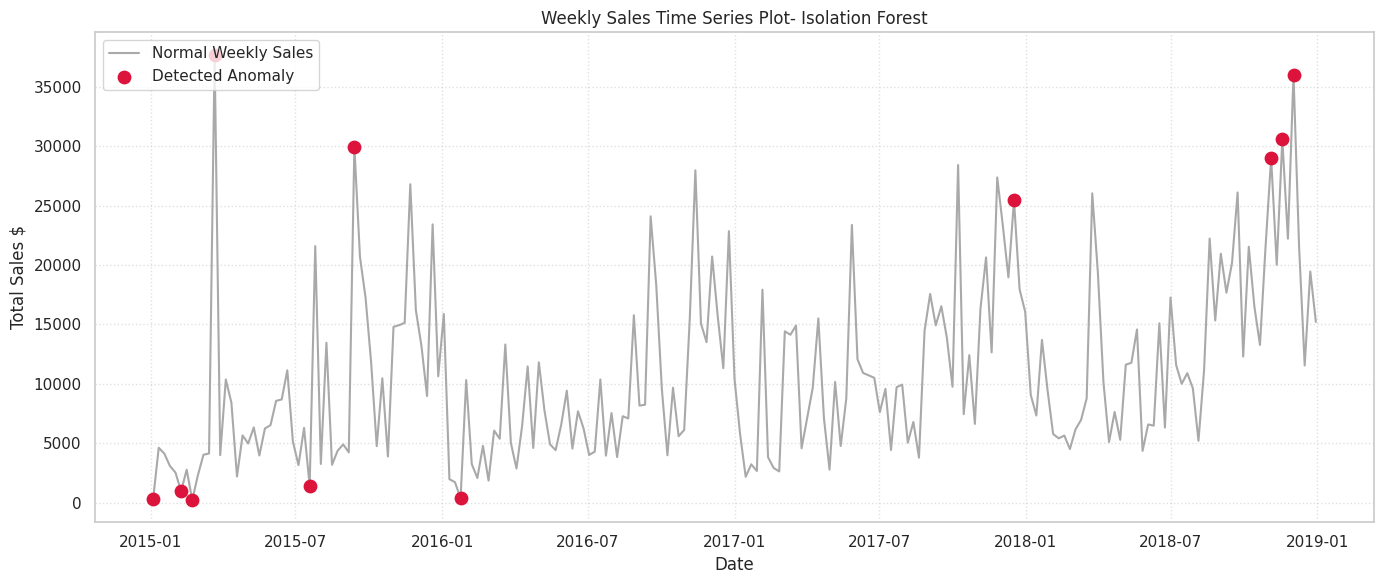

In [21]:
# Importing Isolation Forest model
from sklearn.ensemble import IsolationForest
# creating dataset day-wise
weekly_sales=df.resample('W',on='Order Date')['Sales'].sum().to_frame()
# building the model
iso_forest=IsolationForest(contamination=0.05,random_state=42)
weekly_sales['ISO_Anomaly']=iso_forest.fit_predict(weekly_sales[['Sales']])
weekly_sales['is_anomaly_iso']=weekly_sales['ISO_Anomaly']==-1

# plotting the anomalies on a time series plot
plt.figure(figsize=(14,6))
plt.plot(weekly_sales.index,weekly_sales['Sales'],color='darkgrey',label='Normal Weekly Sales',linewidth=1.5)
anomalies=weekly_sales[weekly_sales['is_anomaly_iso']]
anomaly_df = anomalies.reset_index()[['Order Date', 'Sales']]

# Rename columns for Streamlit
anomaly_df.columns = ['Date', 'Sales']

# Save to CSV
anomaly_df.to_csv("anomalies.csv", index=False)
plt.scatter(anomalies.index,anomalies['Sales'],color='crimson',label='Detected Anomaly',marker='o', s=80, zorder=5)
plt.title('Weekly Sales Time Series Plot- Isolation Forest')
plt.ylabel('Total Sales $',fontsize=12)
plt.xlabel('Date',fontsize=12)
plt.grid(True,linestyle=':',alpha=0.6)
plt.legend(loc='upper left',fontsize=11)
plt.tight_layout()
plt.show()
plt.close()

Question. Explanation for each anomaly detected

Ans.
1. Anomalies 1,2 and 3 near January-2015 : These anomalies occur because people go through post holiday retail hangover after major festive season. Consumer spending usually cools down in the first quarter of the new year, hence the low sales. Additionally, this can occur due to data logging anomalies and system reset anomalies common at the start of the new fiscal year.

2. Anomaly 4 (July 2015) : July sees a dip in sales because of the summer vacations. Business procurement stalls out and purchasing departments do not operate at the active capacity they usually do while decision makers are out of the office.

3. Anomaly 5 (September,October 2015): These months see a surge in Sales because of Back to School Season and reopening of offices resulting in major annual business restocking.Institutions and offices place massive bulk orders during this period

4. Anomaly 6 (January 2016) : January month sees low sales again because of post-holiday cutbacks on corporate consumption and regular seasonal budget freezes at change of calender year.

5. Anomaly 7 (December 2017) : December experiences a surge in Sales because of festivals and public holidays like Christmas and New Year. Offices place bulk orders for gifts for employees, people buy gifts for their acquaintances and corporations flush out their remaining annual budget allocations before they expire on January 1st.

6. Anomaly 8,9,10 (October, November, December 2018) : Again as festive season arrives, massive holidays like Black Friday, Cyber Monday cause the sales going up abnormally and result in anomalies during this time.

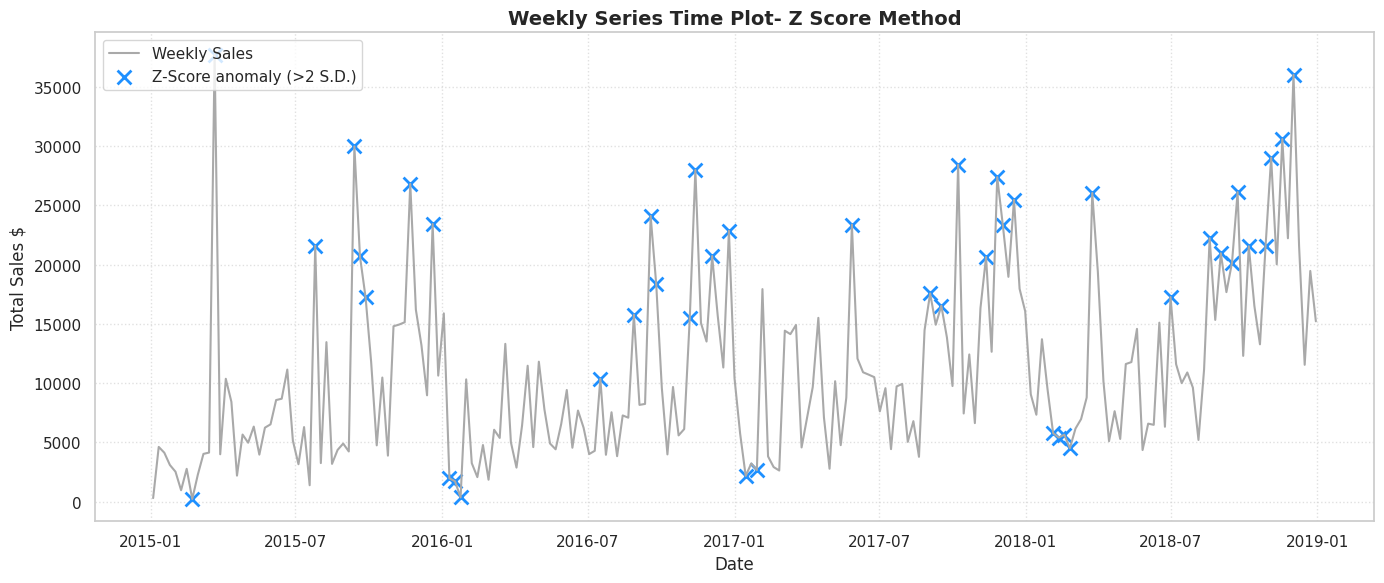

count    209.000000
mean       0.178959
std        1.014794
min       -1.371046
25%       -0.576570
50%        0.061580
75%        0.738155
max        3.667786
Name: Z_scores, dtype: float64
                 Sales  ISO_Anomaly  is_anomaly_iso  Z_scores  is_anomaly_z
Order Date                                                                 
2015-02-22    224.9120           -1            True -1.255254          True
2015-03-22  37703.6650           -1            True  3.141100          True
2015-07-26  21590.0800            1           False  1.930063          True
2015-09-13  29959.1370           -1            True  2.485115          True
2015-09-20  20685.8320            1           False  1.888439          True
2015-09-27  17249.3338            1           False  1.265288          True
2015-11-22  26793.6235            1           False  2.098581          True
2015-12-20  23416.4530            1           False  1.453943          True
2016-01-10   1973.4440            1           Fal

In [15]:
# ANOMALY DETECTION METHOD 2- Z SCORE BASED DETECTION
# calculating a 4 week rolling Z-score to identify outliers
window=26;
rolling_mean= weekly_sales['Sales'].rolling(window=window,min_periods=1).mean()
rolling_std=weekly_sales['Sales'].rolling(window=window,min_periods=1).std().fillna(0)

# calculating z-score for using z=(value-mean)/std_dev
weekly_sales['Z_scores']=(weekly_sales['Sales']-rolling_mean)/(rolling_std+ 1e-5)# we have added a tiny epsilon to avoid division by zero
weekly_sales['is_anomaly_z']=weekly_sales['Z_scores'].abs()>1.2 #pts greater than 2 sd are chosen because according to empirical law, ~95% data falls within this boundary

plt.figure(figsize=(14,6))
plt.plot(weekly_sales.index,weekly_sales['Sales'],color='darkgrey',label='Weekly Sales')
z_anomalies=weekly_sales[weekly_sales['is_anomaly_z']]
plt.scatter(z_anomalies.index,z_anomalies['Sales'],color='dodgerblue',marker='x',s=100,linewidths=2,label= 'Z-Score anomaly (>2 S.D.)')

plt.title('Weekly Series Time Plot- Z Score Method',fontsize=14,fontweight='bold')
plt.ylabel('Total Sales $')
plt.xlabel('Date')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':',alpha=0.6)
plt.tight_layout()
plt.show()
plt.close()


print(weekly_sales['Z_scores'].describe())
print(weekly_sales[weekly_sales['is_anomaly_z']])

The two models highly disagree based on what they consider outliers. The -score model did not flag any point above 2 s.d. Upon research I found that the highest standard deviation in the dataset is 1.5. Hence I set the outlier threshold to 1.2, which flagged 24 anomalies, creating dense clusters that disagree with the 10 point clean isolation anomalies caught by Isolation Forest.

This tells us that Isolation Forest is a Global Filter that reviews the entire 4-year history simultaneously. It only cares if a point is an absolute extreme peak or valley across the whole 4-year timeline

On the other hand, we find out that rolling Z-score is a hyper-local filter and compares each week only to the weeks immediately preceding it, instead of finding out absolute outliers, hence leading to a larger number of anomaly flags.

In [16]:
try:
  vg_df=pd.read_csv('vgsales.csv')
  vg_df['Year']=pd.to_numeric(vg_df['Year'],errors='coerce')

  # Restricting trends to match corporate window
  # Change your old line to this:
  vg_macro = vg_df[vg_df['Year'].between(2015, 2018)].groupby('Year')['Global_Sales'].sum().reset_index()
  vg_macro.columns=['Year','GVGSales_mill']
  superstore_yearly=weekly_sales.groupby(weekly_sales.index.year)['Sales'].sum().reset_index()
  superstore_yearly.columns=['Year','SS_Total_Sales']
  macro_anomaly=pd.merge(superstore_yearly,vg_macro,on='Year',how='left')
  print("MULTI-SOURCE INTEGRATED ANOMALY CONTEXT MATRIX")
  print(macro_anomaly.to_string(index=False))
except Exception as e:
  print(f"Multi source alignment file missing/error occured: {e}")
print(weekly_sales['Z_scores'].describe())
print(weekly_sales[weekly_sales['is_anomaly_z']])

MULTI-SOURCE INTEGRATED ANOMALY CONTEXT MATRIX
 Year  SS_Total_Sales  GVGSales_mill
 2015     467675.8651         264.44
 2016     461194.5312          70.93
 2017     610614.3672           0.05
 2018     722052.0192            NaN
count    209.000000
mean       0.178959
std        1.014794
min       -1.371046
25%       -0.576570
50%        0.061580
75%        0.738155
max        3.667786
Name: Z_scores, dtype: float64
                 Sales  ISO_Anomaly  is_anomaly_iso  Z_scores  is_anomaly_z
Order Date                                                                 
2015-02-22    224.9120           -1            True -1.255254          True
2015-03-22  37703.6650           -1            True  3.141100          True
2015-07-26  21590.0800            1           False  1.930063          True
2015-09-13  29959.1370           -1            True  2.485115          True
2015-09-20  20685.8320            1           False  1.888439          True
2015-09-27  17249.3338            1          

Description of the Superstore sales vs Global Video Games Sales

Ans. This multi-source merge proves that our business anomalies are completely independent of macro entertainment retail indicators. While global video game tracking shows data drop offs, our Superstore shows aggressive, healthy growth. This indicates that these anomalies occurred due to internal drivers (like B2B client acquisitions or specific sales promotions) rather than broader retail market crashes.

# TASK 6- Product Demand Segmentation using Clustering

In [17]:
# Aggregating data at the product sub-category level with features Total sales volume,Sales growth rate (year-over-year)
# Sales volatility (standard deviation of monthly sales), Average order value
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
sub_stats= df.groupby('Sub-Category').agg(
    Total_Sales=('Sales','sum'),
    Avg_Order_Value=('Sales','mean')
).reset_index()
monthly_subcat= df.groupby(['Sub-Category','Year','Month'])['Sales'].sum().reset_index()
volatile=monthly_subcat.groupby('Sub-Category')['Sales'].std().fillna(0).reset_index()
volatile.columns=['Sub-Category','Sales_Volatility']

yearly_sub=df.groupby(['Sub-Category','Year'])['Sales'].sum().unstack().fillna(0)
yearly_sub['YoY_Growth']=(yearly_sub.iloc[:,-1]-yearly_sub.iloc[:,0])/(yearly_sub.iloc[:,0]+1e-5)
growth=yearly_sub[['YoY_Growth']].reset_index()
features_df=sub_stats.merge(volatile,on='Sub-Category').merge(growth,on='Sub-Category')
features_df.set_index('Sub-Category',inplace=True)
scaler=StandardScaler()
scaled_features=scaler.fit_transform(features_df)




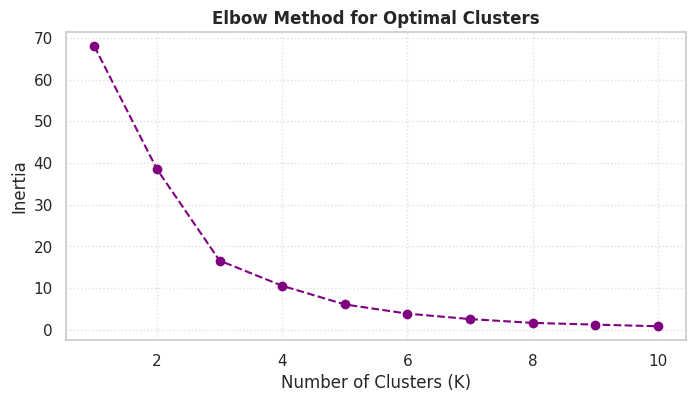

In [18]:
# Elbow Method to find optimal clusters
inertia=[]
K_range=range(1,11)
for k in K_range:
  kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
  kmeans.fit(scaled_features)
  inertia.append(kmeans.inertia_)


plt.figure(figsize=(8,4))
plt.plot(K_range,inertia, marker='o',color='purple',linestyle='--')
plt.title('Elbow Method for Optimal Clusters',fontsize=12,fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True,linestyle=':',alpha=0.6)
plt.show()
plt.close()
# from the plot, we can see that the straight line starts forming at k=3, hence we go ahead with it

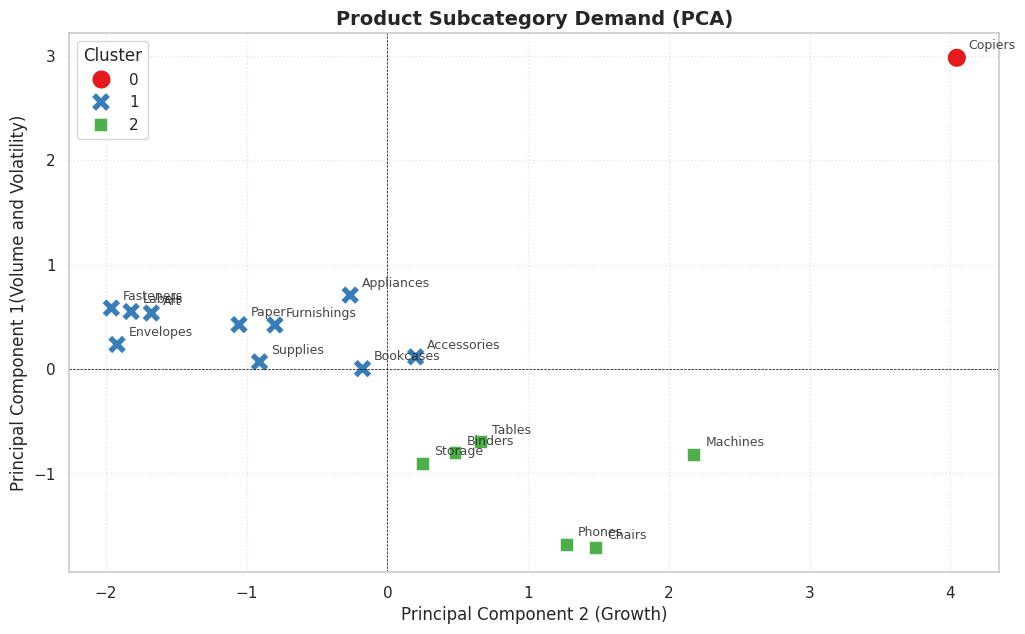

          Total_Sales  Sales_Volatility  YoY_Growth  Avg_Order_Value
Cluster                                                             
0        146248.09400       5500.774391    4.797295      2215.880212
1         65326.20737       1186.287889    0.674218       150.189900
2        243671.10250       3992.982732    0.273237       599.193752


In [22]:
# going ahead with k=3 and performing pca and clustering
optimal_k=3
kmeans_final=KMeans(n_clusters=optimal_k,random_state=42,n_init=10)
features_df['Cluster']=kmeans_final.fit_predict(scaled_features)
pca= PCA(n_components=2)
pca_features=pca.fit_transform(scaled_features)
features_df['PCA1']=pca_features[:,0]
features_df['PCA2']=pca_features[:,1]
cluster_df = features_df[['PCA1', 'PCA2', 'Cluster']].copy()

# Rename columns to match Streamlit app
cluster_df.columns = ['Feature1', 'Feature2', 'Cluster']

# Save to CSV
cluster_df.to_csv("clusters.csv", index=False)
# plotting in a scatter plot
plt.figure(figsize=(12,7))
sns.scatterplot(
    data=features_df,x='PCA1',y='PCA2',hue='Cluster',palette='Set1',s=200,style='Cluster',markers=True
)
for idx,row in features_df.iterrows():
  plt.text(row['PCA1']+0.08,row['PCA2']+0.08,idx,fontsize=9,fontweight='medium',alpha=0.85)

plt.title('Product Subcategory Demand (PCA)',fontsize=14,fontweight='bold')
plt.ylabel('Principal Component 1(Volume and Volatility)')
plt.xlabel('Principal Component 2 (Growth)')
plt.grid(True,linestyle=':',alpha=0.5)
plt.axhline(0,color='black',linewidth=0.5,linestyle='--')
plt.axvline(0,color='black',linewidth=0.5,linestyle='--')
plt.tight_layout
plt.show()
plt.close()

# Computing the profile averages for each cluster group
profile = features_df.groupby('Cluster')[['Total_Sales', 'Sales_Volatility', 'YoY_Growth', 'Avg_Order_Value']].mean()
print(profile)

In [20]:
cluster_labels={
    0: 'Growing Demand',
    1:' Low Volume, Stable Demand',
    2: 'High Volume, Stable Demand'
}
features_df['Demand_Segment']=features_df['Cluster'].map(cluster_labels)

# making a table to view summary of the whole business
segment_summary = features_df.groupby('Demand_Segment').agg(
    Total_SubCategories=('Cluster', 'count'),
    Avg_Total_Sales=('Total_Sales', 'mean'),
    Avg_Volatility=('Sales_Volatility', 'mean'),
    Avg_YoY_Growth=('YoY_Growth', 'mean'),
    Avg_Order_Value=('Avg_Order_Value', 'mean')
).round(2)
segment_summary

,Total_SubCategories,Avg_Total_Sales,Avg_Volatility,Avg_YoY_Growth,Avg_Order_Value
Demand_Segment,,,,,
"Low Volume, Stable Demand",10,65326.21,1186.29,0.67,150.19
Growing Demand,1,146248.09,5500.77,4.80,2215.88
"High Volume, Stable Demand",6,243671.10,3992.98,0.27,599.19


Question. Stocking strategy for each cluster

Ans
1. Cluster 1(Copiers -High Growth) : Since this cluster has a massive YoY growth (4.8) , we need to keep it **stocked ahead of the curve** , as relying on historical sales metrics will likely cause understocking.
Recommendation: ** Dynamic Demand Scaling** Continuously raise inventory caps month over month and instead of looking backwards use the best forecasting models to buy stock before growth hits.
2. Cluster 2(High Volume, Stable Demand): This cluster brings in biggest revenue, so we need to stock efficiently in bulk. Its growth is little and highly predictable
Recommendation: **Fixed Period Bulk Replenishment** since these items move consistenly, purchase them in large and bulk to negotiate wholesale discounts from vendors, which maximises profit margins.
3. Cluster 3 (Low Volume, Stable Demand) : They have low revenue contributions and tiny order values , but they have very low volatility. Hence, they are completely steady.
Recommendation: ** Just in Time Replenishment** Do not waste valuable warehouse space to store huge amounts of these items. Set low baseline safety stocks and set up automated reorder triggers in inventory system. This keeps capital completely free for high-growth products.